Imports

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import gc

Import Data and Fill NaN Values

In [ ]:
DATA_GLOB = "data/Refit/*.csv"

DATA_GLOB = DATA_GLOB.replace("*.csv", "*[!hourly_Temp_data].csv")  # exclude "hourly_Temp_data.csv" files

print("Looking for files in:", DATA_GLOB)

# This function loads the hourly energy consumption data from a CSV file, processes it to ensure it has a DateTime index, and resamples it to ensure it has hourly frequency.
# The function's parameter is :
# - path: The path to the CSV file containing the hourly energy consumption data.
def load_household_hourly(path):
    df = pd.read_csv(path)
    df.rename(columns={'Time': 'Date', 'Aggregate': 'Volume'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.set_index('Date')

    df = df.resample('1h').mean()
    df = df.reset_index()    

    return df

# This function takes the hourly data and creates a daily matrix where each row corresponds to a day and each column corresponds to an hour of the day.
# This function's parameter is :
# - df_hourly: A DataFrame containing hourly energy consumption data with a 'Date' column and a 'Volume' column.
def make_daily_matrix(df_hourly):
    df = df_hourly.copy()
    df['Day'] = df['Date'].dt.date
    df['Hour'] = df['Date'].dt.hour
    df['Weekday'] = df['Date'].dt.weekday
    df['Month'] = df['Date'].dt.month

    group_median = (
        df
        .groupby(['Month', 'Weekday', 'Hour'])['Volume']
        .median()
        )
    def fill_with_group_median(row):
        if pd.isna(row['Volume']):
            return group_median.loc[(row['Month'], row['Weekday'], row['Hour'])]
        else:
            return row['Volume']

    # Number of missing values in Volume before filling with group median
    missing_count = df['Volume'].isna().sum()
    print(f"Missing values before filling: {missing_count} out of {len(df)} ({missing_count/len(df)*100:.2f}%)")
    missing_groups = (df['Volume'].isna() != df['Volume'].isna().shift()).cumsum()
    longest_gap = df[df['Volume'].isna()].groupby(missing_groups).size().max()
    print(f"Longest gap of missing values : {longest_gap} entries, which is {longest_gap / len(df) * 100:.2f}% of total entries.")
        

    df['Volume'] = df.apply(fill_with_group_median, axis=1)

    # restrict to time window from 2014-04-01 to 2015-04-01
    df = df[(df['Date'] >= '2014-04-01') & (df['Date'] < '2015-04-01')]

    daily_matrix = df.pivot_table(index='Day',
                                  columns='Hour',
                                  values='Volume')
    daily_matrix = daily_matrix.dropna()
    daily_matrix = daily_matrix.reindex(columns=range(24))
    return daily_matrix


Looking for files in: data/Refit/*[!hourly_Temp_data].csv


DBSCAN Clustering Function

In [ ]:
# This function applies DBSCAN to the daily profiles and computes metrics about the clustering results.
# This Function's parameters are :
# - daily_matrix: A DataFrame where each row corresponds to a day and each column corresponds to an hour of the day, containing the energy consumption values.
def dbscan_daily_profiles(daily_matrix):
    X = daily_matrix.values  

    daily_energy = X.sum(axis=1)
    avg_daily_energy = daily_energy.mean()

    eps = 0.10 * avg_daily_energy
    min_samples = 2

    db = DBSCAN(eps=eps,
                min_samples=min_samples,
                metric='euclidean')
    labels = db.fit_predict(X)

    n_days = len(labels)
    n_outliers = np.sum(labels == -1)
    frac_outliers = n_outliers / n_days

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    metrics = {
        "n_days": n_days,
        "n_clusters": n_clusters,
        "n_outliers": n_outliers,
        "frac_outliers": frac_outliers,
        "avg_daily_energy": avg_daily_energy,
        "eps_used": eps,
    }
    return labels, metrics


Main Loop to Process Each Household and Run DBSCAN

Combined DataFrame shape: (261064, 1)
                          Volume
Date                            
2013-09-17 22:00:00   277.643275
2013-09-17 23:00:00    93.307179
2013-09-18 00:00:00    93.646667
2013-09-18 01:00:00    63.625000
2013-09-18 02:00:00    91.045151
...                          ...
2015-07-10 07:00:00  2002.994555
2015-07-10 08:00:00  2009.898336
2015-07-10 09:00:00  1986.615101
2015-07-10 10:00:00  2000.506446
2015-07-10 11:00:00  2013.206628

[15854 rows x 1 columns]


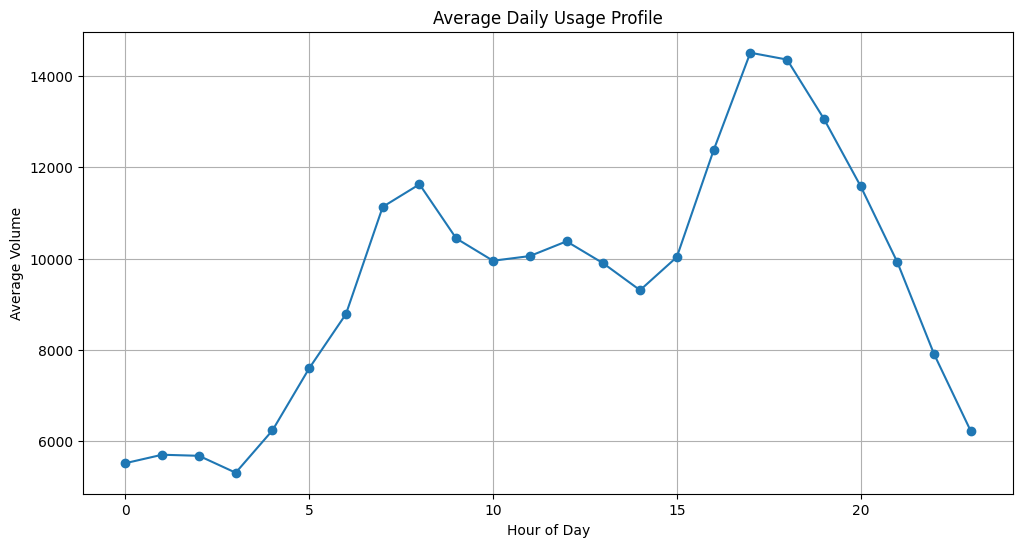

  Found 1 clusters, 1 outliers out of 365 days.
   n_days  n_clusters  n_outliers  frac_outliers  avg_daily_energy  \
0     365           1           1        0.00274     227554.613408   

       eps_used  
0  22755.461341  


In [ ]:
house_metrics = []
dfs = []

for path in glob.glob(DATA_GLOB):
    hid = os.path.splitext(os.path.basename(path))[0]
    df = pd.read_csv(path, usecols=['Time', 'Aggregate'])
    df.rename(columns={'Time': 'Date', 'Aggregate': 'Volume'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

    df = df.set_index('Date')
    df = df.resample('1h').mean()
    dfs.append(df)

del df
gc.collect()

for i in range(len(dfs)):
    if i == 0:
        combined_df = dfs[i]
    else:
        combined_df = pd.concat([combined_df, dfs[i]], axis=0)

print("Combined DataFrame shape:", combined_df.shape)
del dfs
gc.collect()

combined_df = combined_df.groupby(combined_df.index).agg({'Volume': 'sum'})
combined_df = combined_df.reset_index()

daily_matrix = make_daily_matrix(combined_df)

labels, metrics = dbscan_daily_profiles(daily_matrix)
print(f"  Found {metrics['n_clusters']} clusters, "
      f"{metrics['n_outliers']} outliers "
      f"out of {metrics['n_days']} days.")

house_features = pd.DataFrame([metrics])
print(house_features)


